# Task 11 — Video Game Industry Analysis
**Goal:** understand the video game market (games, platforms, genres, publishers, regions, ratings) and turn the data into recommendations a gaming company can act on.

**Source files (in `data/raw/`)**
| File | Rows | Role in this analysis |
|---|---|---|
| `Video_Games_Sales_as_at_22_Dec_2016.csv` | 16,719 | **Main dataset** – all platforms, 1980-2016, regional sales + critic/user scores |
| `PS4_GamesSales.csv` | 1,034 | Supplementary – PS4 titles through 2019/20 (different, newer snapshot) |
| `XboxOne_GameSales.csv` | 613 | Supplementary – Xbox One titles through 2019/20 |

All sales figures are in **millions of units**. The two console files overlap the main file for 2013-2016 and use a different genre taxonomy, so adding them to the main table would double-count sales; they are used only in Section 9 as a post-2016 cross-check.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy import stats
import warnings, os; warnings.filterwarnings('ignore')
os.makedirs('../charts', exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi':110,'axes.titleweight':'bold','axes.titlesize':13,'axes.spines.top':False,'axes.spines.right':False})
BLUE, ORANGE, GREY = '#2F5D8A', '#E07B39', '#9AA5B1'
def save(name): plt.tight_layout(); plt.savefig(f'../charts/{name}.png', dpi=150, bbox_inches='tight'); plt.show()

## 1. Data Understanding

In [2]:
raw = pd.read_csv('../data/raw/Video_Games_Sales_as_at_22_Dec_2016.csv')
print(raw.shape); raw.head()

(16719, 16)


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


### Column dictionary (main dataset)
| Column | Meaning | Type |
|---|---|---|
| `Name` | Game title | text |
| `Platform` | Console / handheld / PC the release was sold on (31 values, e.g. PS2, X360, Wii, PC) | categorical |
| `Year_of_Release` | Release year | integer (stored as float because of NaN) |
| `Genre` | Game genre (12 values) | categorical |
| `Publisher` | Company that published the game | text |
| `NA_Sales`, `EU_Sales`, `JP_Sales`, `Other_Sales` | Sales in North America, Europe, Japan, rest of world (millions of units) | float |
| `Global_Sales` | Worldwide sales (millions of units) | float |
| `Critic_Score` / `Critic_Count` | Metacritic aggregate score (0-100) / number of critics | float / integer |
| `User_Score` / `User_Count` | Metacritic user score (0-10) / number of users | float / integer |
| `Developer` | Studio that built the game | text |
| `Rating` | ESRB age rating (E, E10+, T, M, ...) | categorical |

**Granularity:** one row = one game *on one platform*. A multi-platform title (e.g. GTA V) appears several times, so "best-selling game" is answered both ways below.

In [3]:
profile = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing': raw.isna().sum(), 'missing_%': (raw.isna().mean()*100).round(1), 'unique': raw.nunique()})
profile

,dtype,missing,missing_%,unique
Name,str,2,0.0,11562
Platform,str,0,0.0,31
Year_of_Release,float64,269,1.6,39
Genre,str,2,0.0,12
Publisher,str,54,0.3,582
NA_Sales,float64,0,0.0,402
EU_Sales,float64,0,0.0,307
JP_Sales,float64,0,0.0,244
Other_Sales,float64,0,0.0,155
Global_Sales,float64,0,0.0,629


In [4]:
print('Fully duplicated rows        :', raw.duplicated().sum())
print('Duplicated Name+Platform rows:', raw.duplicated(['Name','Platform']).sum())
print('Rows with no Name & no Genre :', (raw.Name.isna() & raw.Genre.isna()).sum())
print('Years outside 1980-2016      :', (raw.Year_of_Release>2016).sum(), '-> values', sorted(raw.loc[raw.Year_of_Release>2016,'Year_of_Release'].unique()))
print('Names with stray whitespace  :', (raw.Name.dropna().str.strip()!=raw.Name.dropna()).sum())
print('Rating labels                :', raw.Rating.value_counts(dropna=False).to_dict())
diff = (raw[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum(axis=1)-raw.Global_Sales).abs()
print('Max |sum of regions - Global|:', round(diff.max(),2), '(rounding only)')
raw[raw.duplicated(['Name','Platform'], keep=False)].sort_values('Name')[['Name','Platform','Year_of_Release','Publisher','NA_Sales','EU_Sales','Global_Sales']]

Fully duplicated rows        : 0
Duplicated Name+Platform rows: 5
Rows with no Name & no Genre : 2
Years outside 1980-2016      : 4 -> values [np.float64(2017.0), np.float64(2020.0)]
Names with stray whitespace  : 29
Rating labels                : {nan: 6769, 'E': 3991, 'T': 2961, 'M': 1563, 'E10+': 1420, 'EC': 8, 'K-A': 3, 'RP': 3, 'AO': 1}
Max |sum of regions - Global|: 0.02 (rounding only)


,Name,Platform,Year_of_Release,Publisher,NA_Sales,EU_Sales,Global_Sales
604,Madden NFL 13,PS3,2012.0,Electronic Arts,2.11,0.22,2.56
16233,Madden NFL 13,PS3,2012.0,Electronic Arts,0.00,0.01,0.01
1190,Need for Speed: Most Wanted,X360,2012.0,Electronic Arts,0.62,0.78,1.56
1591,Need for Speed: Most Wanted,X360,2005.0,Electronic Arts,1.00,0.13,1.25
5973,Need for Speed: Most Wanted,PC,2005.0,Electronic Arts,0.02,0.23,0.29
11716,Need for Speed: Most Wanted,PC,2012.0,Electronic Arts,0.00,0.06,0.08
1745,Sonic the Hedgehog,PS3,2006.0,Sega,0.41,0.06,1.16
4127,Sonic the Hedgehog,PS3,NaN,NaN,0.00,0.48,0.48
659,NaN,GEN,1993.0,Acclaim Entertainment,1.78,0.53,2.39
14246,NaN,GEN,1993.0,Acclaim Entertainment,0.00,0.00,0.03


### Data-quality findings
| Issue | Size | Decision |
|---|---|---|
| Missing `Name` **and** `Genre` | 2 rows | Drop - unidentifiable |
| Missing `Year_of_Release` | 269 rows (1.6%) | Keep for non-time analysis; excluded from year charts |
| Impossible years (2017, 2020) in a Dec-2016 snapshot | 4 rows | Set to missing |
| Missing `Publisher` | 54 rows | Label `Unknown` |
| Missing `Developer` | ~6.6k rows (40%) | Label `Unknown`; not used for conclusions |
| Missing critic / user scores | ~51% / ~55% | **Not imputed** - scores only exist for games Metacritic covered; score analysis uses rated games only |
| Duplicated Name+Platform | 5 rows | 2 are "split sales" rows of the same release -> merged (sales summed). 3 are genuinely different releases (*Need for Speed: Most Wanted* 2005 vs 2012) -> kept |
| Publisher spelling variants | ~9 | Consolidated (e.g. SquareSoft -> Square Enix) |
| Rating `K-A` (old name of `E`), `RP` (pending) | 6 rows | K-A -> E; RP -> missing |
| Stray whitespace in text | 29 names | Trimmed |

## 2. Data Cleaning
The full pipeline is below (also saved as `clean.py`). Every step is logged so the effect on the data is transparent.

In [5]:
import pandas as pd, numpy as np

RAW = '../data/raw/Video_Games_Sales_as_at_22_Dec_2016.csv'
log = []
df = pd.read_csv(RAW)
n0 = len(df); log.append(('Raw rows loaded', n0, ''))

# 1. Column names -> consistent style
df = df.rename(columns={'Name':'Name','Year_of_Release':'Year','NA_Sales':'NA_Sales','EU_Sales':'EU_Sales',
                        'JP_Sales':'JP_Sales','Other_Sales':'Other_Sales','Global_Sales':'Global_Sales'})

# 2. Text hygiene
for c in ['Name','Publisher','Developer','Genre','Platform','Rating']:
    df[c] = df[c].astype('string').str.strip()
log.append(('Name values with stray whitespace trimmed', int((pd.read_csv(RAW).Name.dropna().str.strip()!=pd.read_csv(RAW).Name.dropna()).sum()), 'e.g. trailing spaces in Name / Publisher'))

# 3. Rows with no Name and no Genre are unusable
bad = df['Name'].isna() & df['Genre'].isna()
log.append(('Rows dropped: missing Name AND Genre', int(bad.sum()), 'Both are Genesis 1993 rows, cannot be identified'))
df = df[~bad].copy()

# 4. Invalid release years (dataset snapshot is Dec-2016)
inv = df['Year'] > 2016
log.append(('Invalid Year set to NaN (>2016)', int(inv.sum()), 'Impossible for a Dec-2016 snapshot (2017 / 2020 values)'))
df.loc[inv,'Year'] = np.nan

# 5. Duplicates: same Name + Platform (and compatible Year) = split sales row -> merge, don't lose sales
sales = ['NA_Sales','EU_Sales','JP_Sales','Other_Sales','Global_Sales']
df['_k'] = df['Name'].str.lower() + '|' + df['Platform']
merged = 0; drop_idx = []
for k, g in df[df.duplicated('_k', keep=False)].groupby('_k'):
    yrs = g['Year'].dropna().unique()
    if len(yrs) > 1:      # different years = genuinely different releases (e.g. NFS Most Wanted 2005 vs 2012)
        continue
    keep = g.sort_values('Global_Sales', ascending=False).index[0]
    for c in sales: df.loc[keep, c] = g[c].sum()
    for c in ['Year','Publisher','Developer','Rating']:
        if pd.isna(df.loc[keep, c]) and g[c].notna().any(): df.loc[keep, c] = g[c].dropna().iloc[0]
    drop_idx += [i for i in g.index if i != keep]; merged += 1
df = df.drop(index=drop_idx).drop(columns='_k')
log.append(('Duplicate Name+Platform rows merged (sales summed)', len(drop_idx), f'{merged} games; kept distinct releases with different years'))

# 6. Missing categorical values
mp = df['Publisher'].isna().sum(); df['Publisher'] = df['Publisher'].fillna('Unknown')
log.append(('Missing Publisher -> "Unknown"', int(mp), ''))
md = df['Developer'].isna().sum(); df['Developer'] = df['Developer'].fillna('Unknown')
log.append(('Missing Developer -> "Unknown"', int(md), ''))

# 7. Standardise Publisher spelling variants
pub_map = {'Square Enix':'Square Enix','SquareSoft':'Square Enix','Square':'Square Enix','Square EA':'Square Enix',
           'Sony Computer Entertainment America':'Sony Computer Entertainment',
           'Sony Computer Entertainment Europe':'Sony Computer Entertainment',
           'Sony Oznline Entertainment':'Sony Online Entertainment','Activision Value':'Activision',
           'Codemasters Online':'Codemasters','Ubisoft Annecy':'Ubisoft'}
before = df['Publisher'].nunique()
df['Publisher'] = df['Publisher'].replace(pub_map)
log.append(('Publisher variants consolidated', before - df['Publisher'].nunique(), 'Square/SquareSoft->Square Enix, Sony CE America/Europe->Sony CE, etc.'))

# 8. Rating: legacy K-A == E; RP (rating pending) -> missing
n_ka = (df['Rating']=='K-A').sum(); n_rp = (df['Rating']=='RP').sum()
df['Rating'] = df['Rating'].replace({'K-A':'E'}); df.loc[df['Rating']=='RP','Rating'] = pd.NA
log.append(('Rating: K-A merged into E; RP set to NaN', int(n_ka+n_rp), ''))

# 9. Data types
df['Year'] = df['Year'].astype('Int64')
for c in ['Critic_Count','User_Count']: df[c] = df[c].astype('Int64')
for c in ['Name','Platform','Genre','Publisher','Developer','Rating']: df[c] = df[c].astype('category' if c in ['Platform','Genre','Rating'] else 'string')

# 10. Feature engineering
df['User_Score_100'] = (df['User_Score']*10).round(1)               # same 0-100 scale as critics
df['Score_Gap'] = df['Critic_Score'] - df['User_Score_100']
maker = {'PS':'Sony','PS2':'Sony','PS3':'Sony','PS4':'Sony','PSP':'Sony','PSV':'Sony',
         'NES':'Nintendo','SNES':'Nintendo','N64':'Nintendo','GC':'Nintendo','Wii':'Nintendo','WiiU':'Nintendo',
         'GB':'Nintendo','GBA':'Nintendo','DS':'Nintendo','3DS':'Nintendo',
         'XB':'Microsoft','X360':'Microsoft','XOne':'Microsoft',
         'SAT':'Sega','DC':'Sega','GEN':'Sega','SCD':'Sega','GG':'Sega','PC':'PC'}
df['Platform_Maker'] = df['Platform'].astype(str).map(maker).fillna('Other')
handheld = {'GB','GBA','DS','3DS','PSP','PSV','GG','WS','NG'}
df['Platform_Type'] = np.where(df['Platform']=='PC','PC', np.where(df['Platform'].astype(str).isin(handheld),'Handheld','Console'))
df['Decade'] = (df['Year']//10*10).astype('Int64').astype('string')+'s'
df.loc[df['Year'].isna(),'Decade'] = pd.NA
df['Critic_Band'] = pd.cut(df['Critic_Score'],[0,50,60,70,80,90,100],labels=['0-49','50-59','60-69','70-79','80-89','90+'])
df['Has_Scores'] = df['Critic_Score'].notna() & df['User_Score'].notna()
log.append(('Score columns left missing (NOT imputed)', int(df['Critic_Score'].isna().sum()), 'Imputing would invent ratings; score analysis uses only rated games'))

# 11. Validity checks
chk = (df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum(axis=1) - df['Global_Sales']).abs()
log.append(('Rows where regions != Global by >0.05M', int((chk>0.05).sum()), 'Differences <=0.02M are rounding; Global kept as reported'))
assert (df[sales]>=0).all().all() and df['Critic_Score'].dropna().between(0,100).all() and df['User_Score'].dropna().between(0,10).all()

df = df.reset_index(drop=True)
log.append(('Final rows', len(df), f'{n0-len(df)} rows removed in total'))
df.to_csv('../data/cleaned_video_games.csv', index=False)
pd.DataFrame(log, columns=['Step','Rows_affected','Note']).to_csv('../data/cleaning_log.csv', index=False)
pd.DataFrame(log, columns=['Step','Rows_affected','Note'])

,Step,Rows_affected,Note
0,Raw rows loaded,16719,
1,Name values with stray whitespace trimmed,29,e.g. trailing spaces in Name / Publisher
2,Rows dropped: missing Name AND Genre,2,"Both are Genesis 1993 rows, cannot be identified"
3,Invalid Year set to NaN (>2016),4,Impossible for a Dec-2016 snapshot (2017 / 202...
4,Duplicate Name+Platform rows merged (sales sum...,2,2 games; kept distinct releases with different...
5,"Missing Publisher -> ""Unknown""",53,
6,"Missing Developer -> ""Unknown""",6621,
7,Publisher variants consolidated,9,"Square/SquareSoft->Square Enix, Sony CE Americ..."
8,Rating: K-A merged into E; RP set to NaN,6,
9,Score columns left missing (NOT imputed),8580,Imputing would invent ratings; score analysis ...


In [6]:
df = pd.read_csv('../data/cleaned_video_games.csv')
df['Year'] = df['Year'].astype('Int64')
TOTAL = df.Global_Sales.sum()
print(f'{len(df):,} rows | {df.Name.nunique():,} unique titles | {TOTAL:,.0f}M units | {df.Year.min()}-{df.Year.max()}')
df.info()

16,715 rows | 11,562 unique titles | 8,918M units | 1980-2016
<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            16715 non-null  str    
 1   Platform        16715 non-null  str    
 2   Year            16443 non-null  Int64  
 3   Genre           16715 non-null  str    
 4   Publisher       16715 non-null  str    
 5   NA_Sales        16715 non-null  float64
 6   EU_Sales        16715 non-null  float64
 7   JP_Sales        16715 non-null  float64
 8   Other_Sales     16715 non-null  float64
 9   Global_Sales    16715 non-null  float64
 10  Critic_Score    8135 non-null   float64
 11  Critic_Count    8135 non-null   float64
 12  User_Score      7588 non-null   float64
 13  User_Count      7588 non-null   float64
 14  Developer       16715 non-null  str    
 15  Rating          9945 non-null   str    
 16  User_Score_100  7588 non-

## 3. Exploratory Data Analysis & 4. Visualizations
### 3.1 Market overview

In [7]:
kpi = {'Release records': len(df), 'Unique titles': df.Name.nunique(), 'Total sales (M units)': round(TOTAL,1),
       'Top genre by sales': df.groupby('Genre').Global_Sales.sum().idxmax(),
       'Top platform by sales': df.groupby('Platform').Global_Sales.sum().idxmax(),
       'Top publisher by sales': df.groupby('Publisher').Global_Sales.sum().idxmax(),
       'Peak sales year': int(df.groupby('Year').Global_Sales.sum().idxmax())}
pd.Series(kpi).to_frame('Value')

,Value
Release records,16715
Unique titles,11562
Total sales (M units),8917.9
Top genre by sales,Action
Top platform by sales,PS2
Top publisher by sales,Nintendo
Peak sales year,2008


### 3.2 Which genres are the most common - and do they sell?
**Purpose:** compare *supply* (number of releases) with *demand* (total and per-game sales). A genre can be crowded but weak, or rare but lucrative.

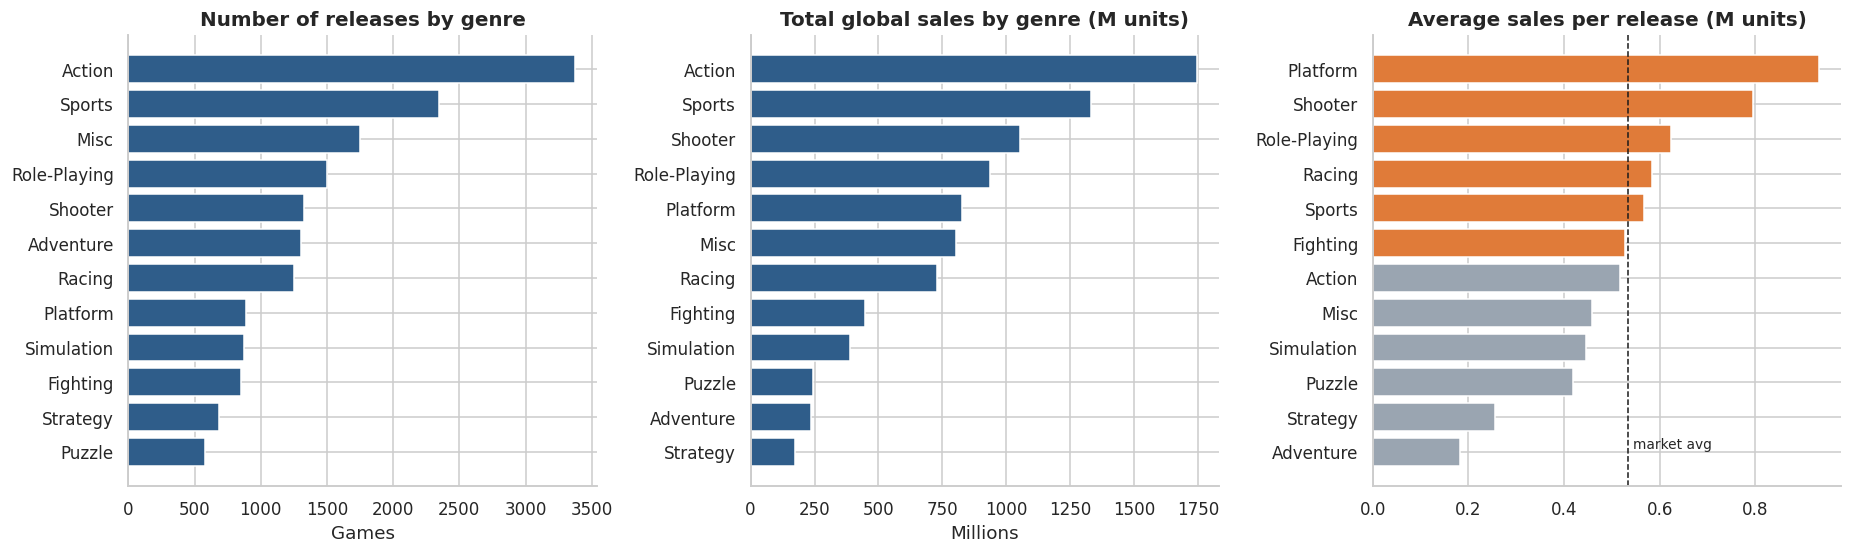

,Games,Total,Avg,Median,Share_%
Genre,,,,,
Action,3370,1745.27,0.52,0.19,19.57
Sports,2347,1332.00,0.57,0.22,14.94
Shooter,1323,1052.94,0.80,0.23,11.81
Role-Playing,1500,934.40,0.62,0.18,10.48
Platform,887,828.08,0.93,0.27,9.29
Misc,1750,803.18,0.46,0.16,9.01
Racing,1249,728.90,0.58,0.19,8.17
Fighting,849,447.48,0.53,0.20,5.02
Simulation,874,390.42,0.45,0.15,4.38


In [8]:
g = df.groupby('Genre').agg(Games=('Name','count'), Total=('Global_Sales','sum'), Avg=('Global_Sales','mean'), Median=('Global_Sales','median'))
g['Share_%'] = g.Total/TOTAL*100
fig, ax = plt.subplots(1,3, figsize=(17,5.2))
o = g.sort_values('Games'); ax[0].barh(o.index, o.Games, color=BLUE); ax[0].set_title('Number of releases by genre'); ax[0].set_xlabel('Games')
o = g.sort_values('Total'); ax[1].barh(o.index, o.Total, color=BLUE); ax[1].set_title('Total global sales by genre (M units)'); ax[1].set_xlabel('Millions')
o = g.sort_values('Avg'); ax[2].barh(o.index, o.Avg, color=[ORANGE if v>=g.Avg.median() else GREY for v in o.Avg]); ax[2].set_title('Average sales per release (M units)')
ax[2].axvline(df.Global_Sales.mean(), color='k', ls='--', lw=1); ax[2].text(df.Global_Sales.mean()+.01, 0.1, 'market avg', fontsize=9)
save('01_genre_overview'); g.sort_values('Total', ascending=False).round(2)

**Insight.** Action is both the most common genre (3,370 releases) and the biggest seller (19.6% of units). But volume is not profitability per title: **Platform (0.93M), Shooter (0.80M) and RPG (0.62M)** earn the most per release, while **Adventure** is the 6th most common genre yet sells only 0.18M per game - an oversupplied niche.

### 3.3 Which platforms have the highest sales?
**Purpose:** rank platforms and show *when* they sold - platform value depends on lifecycle.

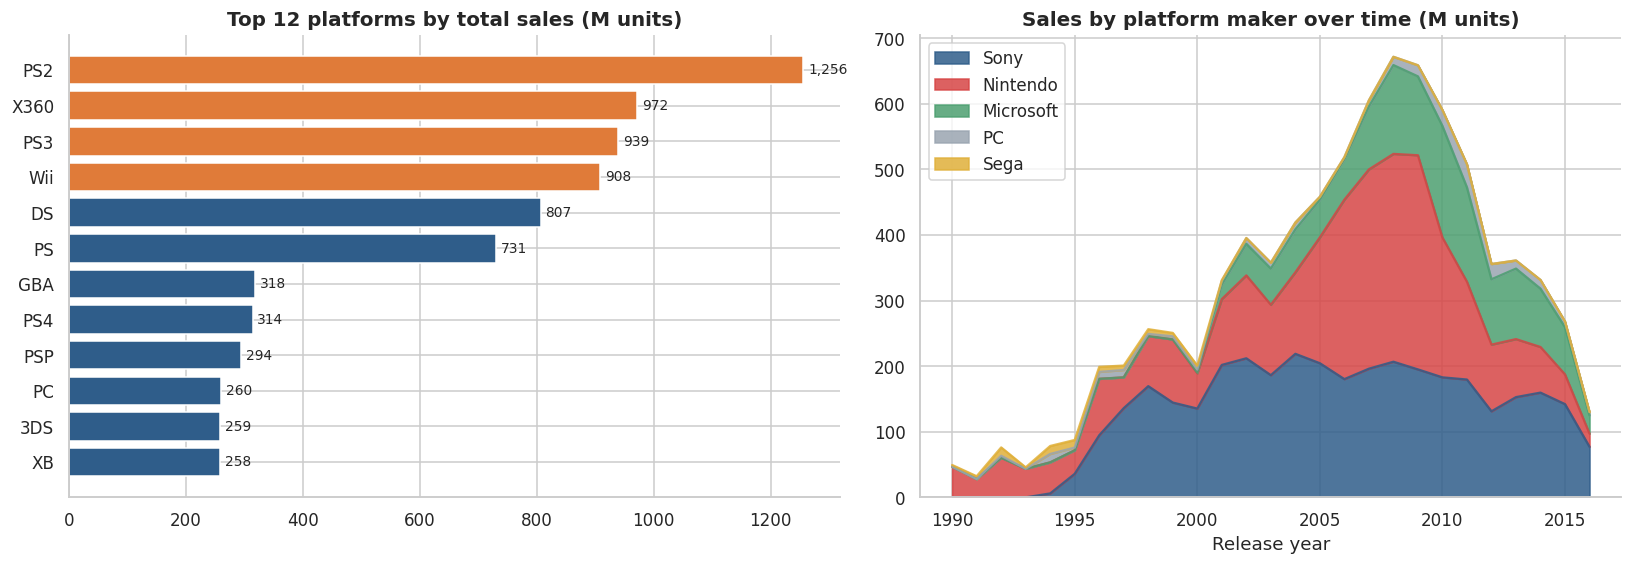

,Total,Games,Avg
Platform,,,
PS2,1255.64,2161,0.58
X360,971.63,1262,0.77
PS3,939.43,1329,0.71
Wii,908.13,1320,0.69
DS,807.10,2152,0.38
PS,730.68,1197,0.61
GBA,318.50,822,0.39
PS4,314.23,393,0.80
PSP,294.30,1209,0.24


In [9]:
p = df.groupby('Platform').agg(Total=('Global_Sales','sum'), Games=('Name','count')); p['Avg'] = p.Total/p.Games
top = p.nlargest(12,'Total').sort_values('Total')
fig, ax = plt.subplots(1,2, figsize=(15,5.3), gridspec_kw={'width_ratios':[1.1,1]})
ax[0].barh(top.index, top.Total, color=[ORANGE if i in ('PS2','X360','PS3','Wii') else BLUE for i in top.index]); ax[0].set_title('Top 12 platforms by total sales (M units)')
for i,(k,v) in enumerate(top.Total.items()): ax[0].text(v+8, i, f'{v:,.0f}', va='center', fontsize=9)
mk = df.groupby(['Year','Platform_Maker']).Global_Sales.sum().unstack().fillna(0).loc[1990:2016]
mk[['Sony','Nintendo','Microsoft','PC','Sega']].plot.area(ax=ax[1], alpha=.85, color=['#2F5D8A','#D64545','#4C9F70','#9AA5B1','#E0B03A'])
ax[1].set_title('Sales by platform maker over time (M units)'); ax[1].set_xlabel('Release year'); ax[1].legend(title='', loc='upper left')
save('02_platform_sales'); p.sort_values('Total', ascending=False).head(10).round(2)

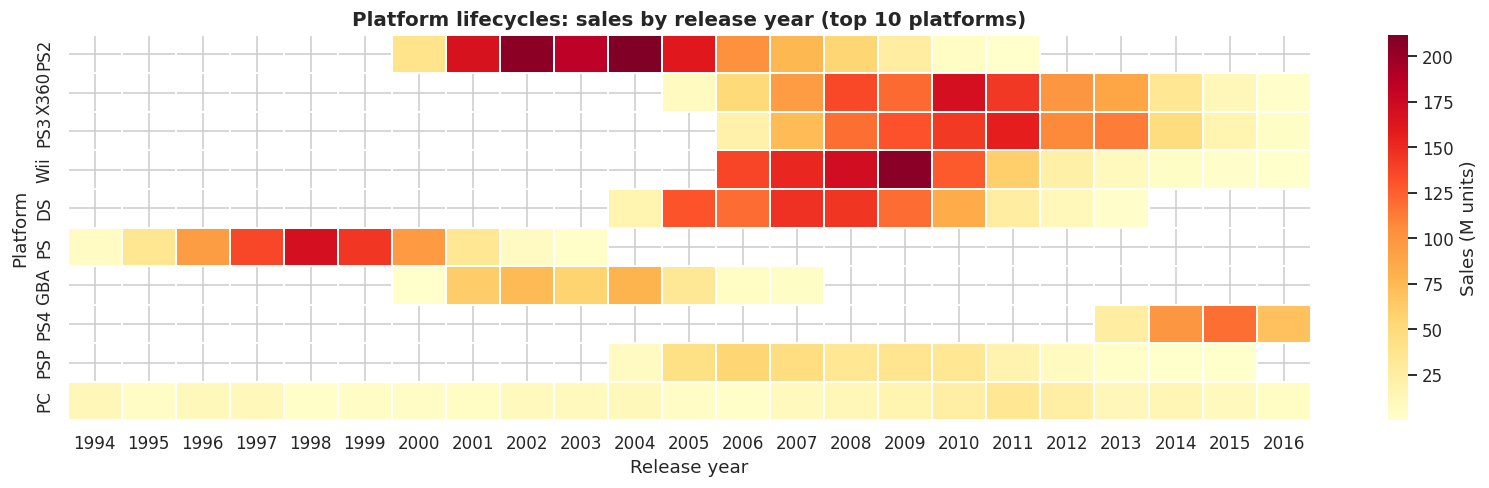

In [10]:
top8 = p.nlargest(10,'Total').index
hm = df[df.Platform.isin(top8)].pivot_table(index='Platform', columns='Year', values='Global_Sales', aggfunc='sum').reindex(top8)
hm = hm.loc[:, 1994:2016]
plt.figure(figsize=(15,4.6)); sns.heatmap(hm, cmap='YlOrRd', linewidths=.3, cbar_kws={'label':'Sales (M units)'}, annot=False)
plt.title('Platform lifecycles: sales by release year (top 10 platforms)'); plt.xlabel('Release year'); save('03_platform_lifecycle')

**Insight.** PS2 leads all-time (1,256M), followed by X360, PS3 and Wii. By maker, **Sony (~3.59B) and Nintendo (~3.50B)** are nearly level, and Microsoft trails at ~1.39B. The heatmap shows every platform has a ~5-8 year hot window, then collapses, so a platform is a *time-limited* bet; the best entry point is early/mid-life, not after the peak.

### 3.4 Which publishers have the highest total sales?
**Purpose:** measure market concentration and separate *scale* from *efficiency* (avg sales per title).

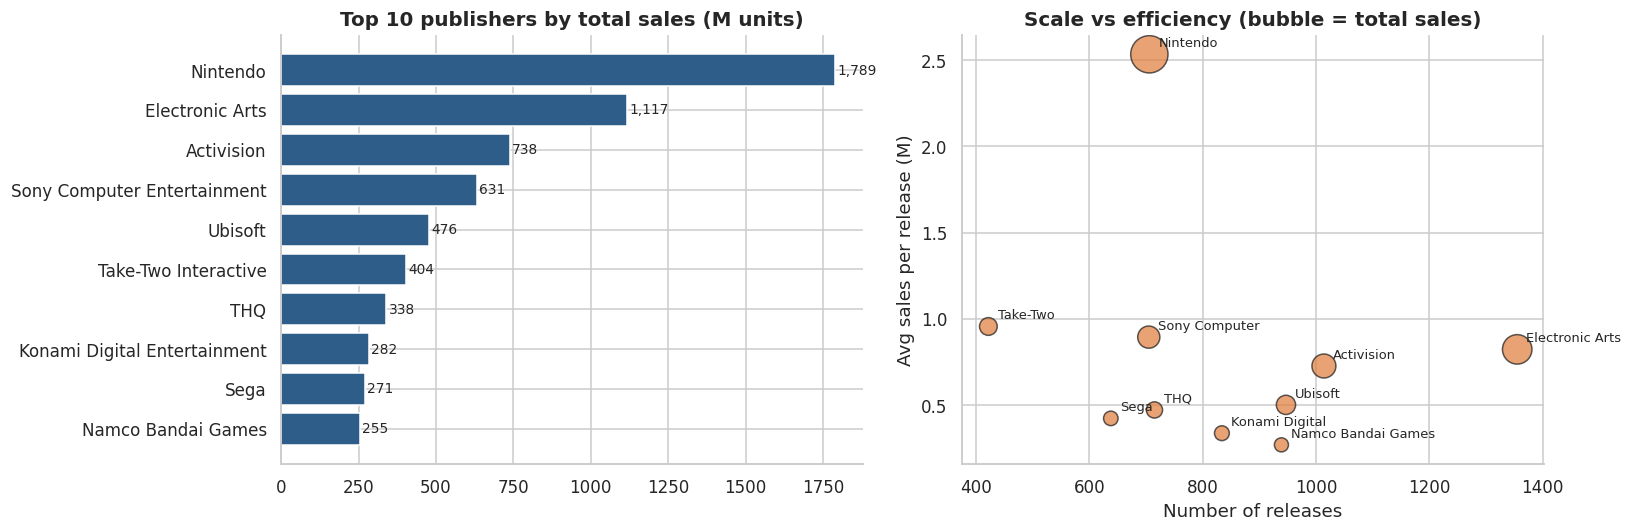

Top-10 publishers hold 70.7% of all units; top-1 (Nintendo) 20.1%


,Total,Games,Avg
Publisher,,,
Nintendo,1788.81,706,2.53
Electronic Arts,1116.96,1355,0.82
Activision,738.11,1014,0.73
Sony Computer Entertainment,631.11,705,0.90
Ubisoft,476.07,947,0.50
Take-Two Interactive,403.82,422,0.96
THQ,338.44,715,0.47
Konami Digital Entertainment,282.39,834,0.34
Sega,270.83,638,0.42


In [11]:
pb = df.groupby('Publisher').agg(Total=('Global_Sales','sum'), Games=('Name','count')); pb['Avg'] = pb.Total/pb.Games
t10 = pb.nlargest(10,'Total')
fig, ax = plt.subplots(1,2, figsize=(15,5))
o = t10.sort_values('Total'); ax[0].barh(o.index, o.Total, color=BLUE); ax[0].set_title('Top 10 publishers by total sales (M units)')
for i,v in enumerate(o.Total): ax[0].text(v+8, i, f'{v:,.0f}', va='center', fontsize=9)
ax[1].scatter(t10.Games, t10.Avg, s=t10.Total/3, color=ORANGE, alpha=.7, edgecolor='k')
for n,r in t10.iterrows(): ax[1].annotate(n.replace(' Entertainment','').replace(' Interactive',''), (r.Games, r.Avg), xytext=(6,5), textcoords='offset points', fontsize=8.5)
ax[1].set_xlabel('Number of releases'); ax[1].set_ylabel('Avg sales per release (M)'); ax[1].set_title('Scale vs efficiency (bubble = total sales)')
save('04_publishers')
print(f'Top-10 publishers hold {t10.Total.sum()/TOTAL:.1%} of all units; top-1 (Nintendo) {t10.Total.iloc[0]/TOTAL:.1%}')
t10.round(2)

**Insight.** Ten publishers hold ~71% of all units. **Nintendo is #1 (1.79B) with only 706 releases - 2.5M units per title, ~3x EA's 0.82M** despite EA shipping nearly twice as many games. Scale (EA, Activision, Ubisoft) and per-title efficiency (Nintendo, Take-Two, Sony) are two distinct winning strategies.

### 3.5 What are the best-selling games?
**Purpose:** show how concentrated hits are. Done two ways: per release (game+platform) and per title (all platforms combined).

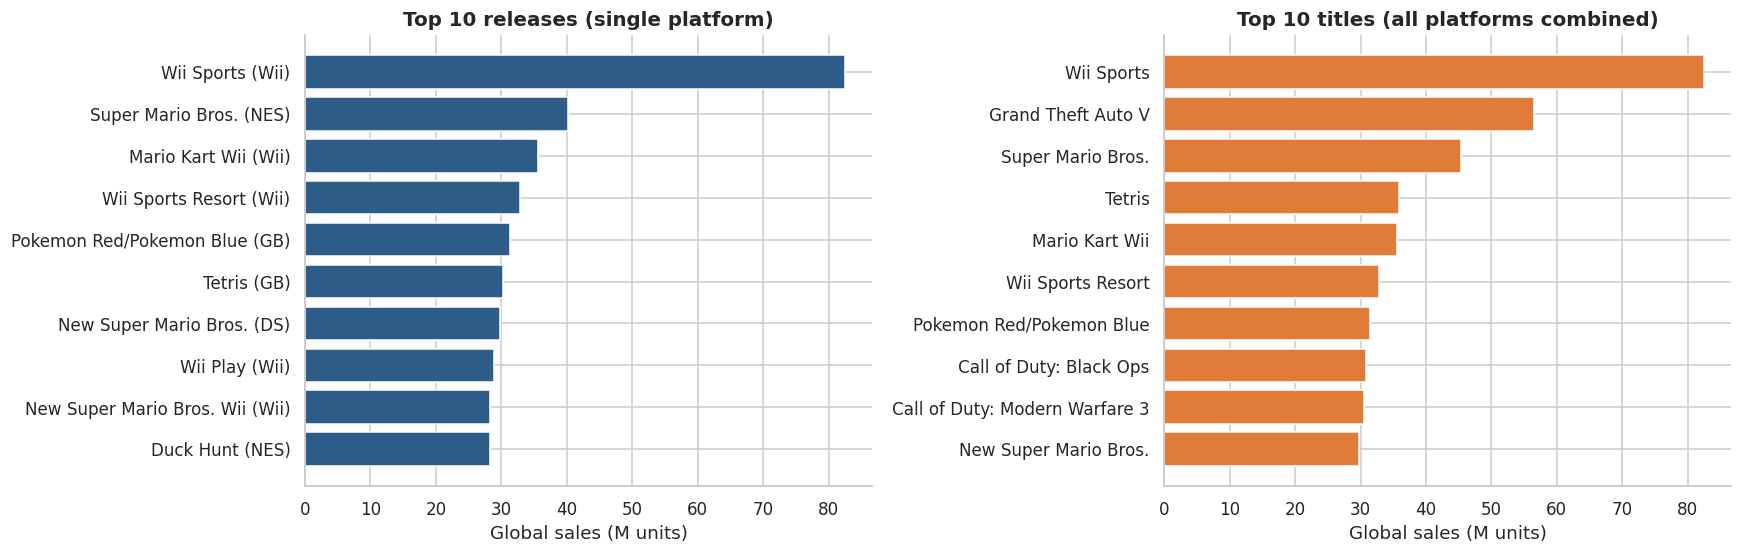

Top 1% of releases = 21% of units | top 10% = 59% | 35% of releases sold < 100k units


,Sales,Platforms
Name,,
Wii Sports,82.53,1
Grand Theft Auto V,56.57,5
Super Mario Bros.,45.31,2
Tetris,35.84,2
Mario Kart Wii,35.52,1
Wii Sports Resort,32.77,1
Pokemon Red/Pokemon Blue,31.37,1
Call of Duty: Black Ops,30.82,5
Call of Duty: Modern Warfare 3,30.59,4


In [12]:
by_rel = df.nlargest(10,'Global_Sales')[['Name','Platform','Year','Global_Sales']]
by_title = df.groupby('Name').agg(Sales=('Global_Sales','sum'), Platforms=('Platform','nunique')).nlargest(10,'Sales')
fig, ax = plt.subplots(1,2, figsize=(16,5.2))
o = by_rel.iloc[::-1]; ax[0].barh(o.Name+' ('+o.Platform+')', o.Global_Sales, color=BLUE); ax[0].set_title('Top 10 releases (single platform)')
o = by_title.iloc[::-1]; ax[1].barh(o.index, o.Sales, color=ORANGE); ax[1].set_title('Top 10 titles (all platforms combined)')
for a in ax: a.set_xlabel('Global sales (M units)')
save('05_best_sellers')
s = df.sort_values('Global_Sales', ascending=False); n=len(s)
print(f"Top 1% of releases = {s.head(int(n*.01)).Global_Sales.sum()/TOTAL:.0%} of units | top 10% = {s.head(int(n*.1)).Global_Sales.sum()/TOTAL:.0%} | {(df.Global_Sales<0.1).mean():.0%} of releases sold < 100k units")
by_title

**Insight.** Wii Sports (82.5M) is almost double the next release. Combined across platforms, **GTA V (56.6M) jumps to #2** - multi-platform launches matter. The market is a *hit business*: the top 1% of releases earn 21% of units, the top 10% earn 59%, and 35% of releases sell under 100k copies.

### 3.6 How have game sales changed over the years?
**Purpose:** find growth, peak and decline. 2016 and the pre-1994 years are flagged because coverage is thin.

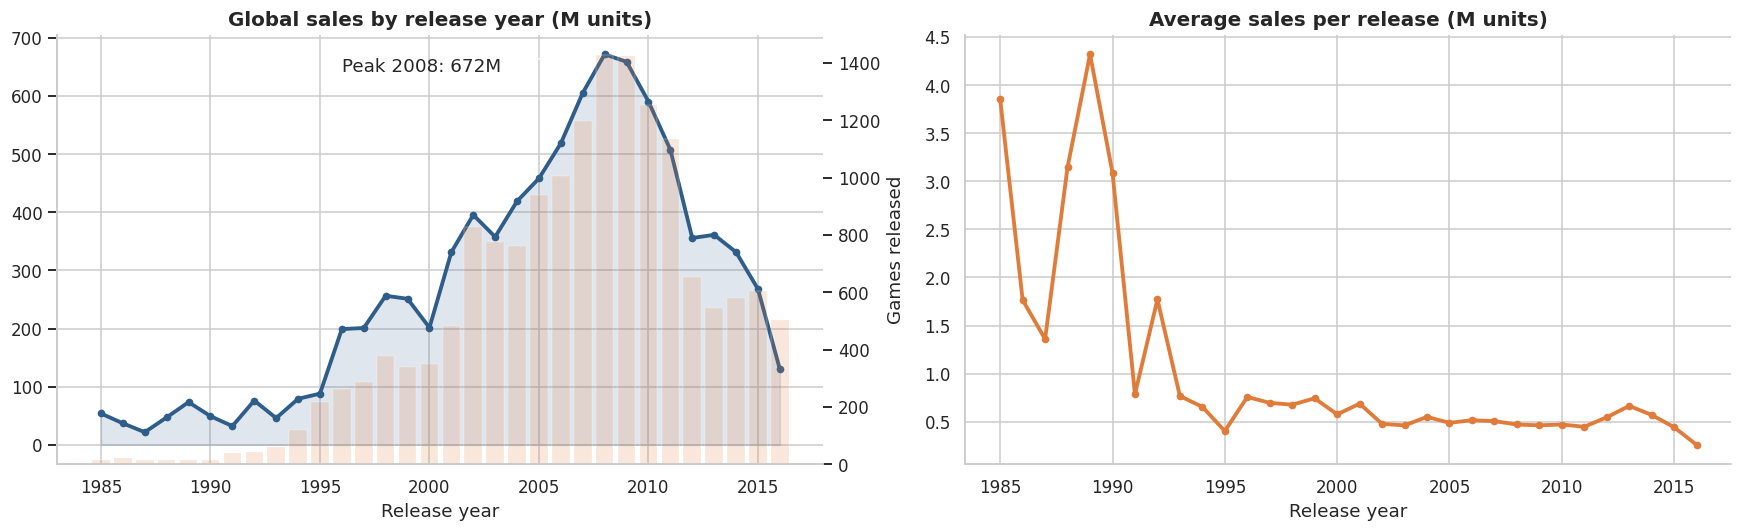

,Sales,Games,PerGame
Year,,,
2005,458.31,939,0.49
2006,518.70,1006,0.52
2007,605.37,1197,0.51
2008,671.79,1427,0.47
2009,658.88,1426,0.46
2010,590.59,1255,0.47
2011,507.79,1136,0.45
2012,355.84,652,0.55
2013,361.24,544,0.66


In [13]:
y = df.dropna(subset=['Year']).groupby('Year').agg(Sales=('Global_Sales','sum'), Games=('Name','count'))
y = y.loc[1985:2016]; y['PerGame'] = y.Sales/y.Games
fig, ax = plt.subplots(1,2, figsize=(16,5))
ax[0].plot(y.index, y.Sales, color=BLUE, lw=2.5, marker='o', ms=4); ax[0].fill_between(y.index, y.Sales, alpha=.15, color=BLUE)
pk = y.Sales.idxmax(); ax[0].annotate(f'Peak {pk}: {y.Sales.max():.0f}M', (pk, y.Sales.max()), xytext=(pk-12, y.Sales.max()-30), arrowprops=dict(arrowstyle='->'))
ax[0].set_title('Global sales by release year (M units)'); ax[0].set_xlabel('Release year')
ax2 = ax[0].twinx(); ax2.bar(y.index, y.Games, alpha=.18, color=ORANGE); ax2.set_ylabel('Games released'); ax2.grid(False)
ax[1].plot(y.index, y.PerGame, color=ORANGE, lw=2.5, marker='o', ms=4); ax[1].set_title('Average sales per release (M units)'); ax[1].set_xlabel('Release year')
save('06_sales_trend')
y.loc[2005:2016].round(2)

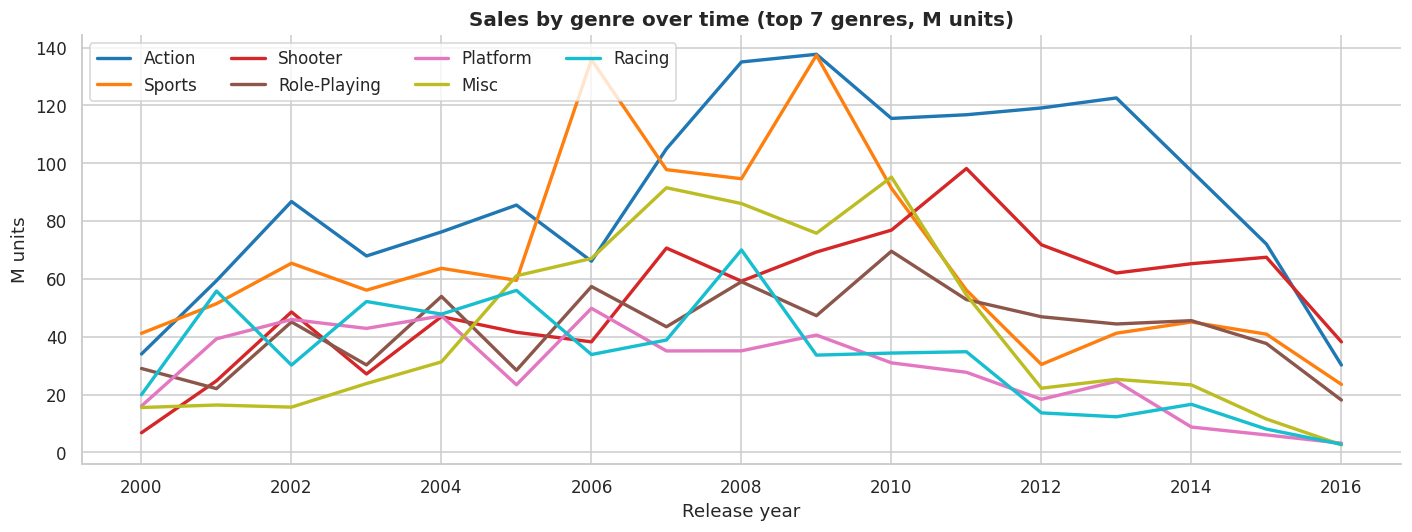

In [14]:
g_year = df[df.Year.between(2000,2016)].pivot_table(index='Year', columns='Genre', values='Global_Sales', aggfunc='sum').fillna(0)
top_g = ['Action','Sports','Shooter','Role-Playing','Platform','Misc','Racing']
g_year[top_g].plot(figsize=(13,5), lw=2.2, colormap='tab10'); plt.title('Sales by genre over time (top 7 genres, M units)'); plt.xlabel('Release year'); plt.ylabel('M units')
plt.legend(ncol=4, loc='upper left'); save('07_genre_trend')

**Insight.** Sales grew almost every year from 1995 to a **peak in 2008 (672M)**, then fell ~80% by 2016. Releases fell too (1,427 -> 502), but **average sales per release held up through 2015** (about 0.4-0.7M vs 0.47M at the 2008 peak) - the market consolidated into fewer, bigger titles. (2016 looks weaker at 0.26M, but it is a partial year.) Caveats: this data tracks mostly physical/retail units (digital and mobile are under-counted), and 2016 is incomplete, so the post-2011 decline is partly a coverage effect, not only a real market contraction.

### 3.7 Which regions generate the highest sales?
**Purpose:** regional mix and regional taste differences by genre.

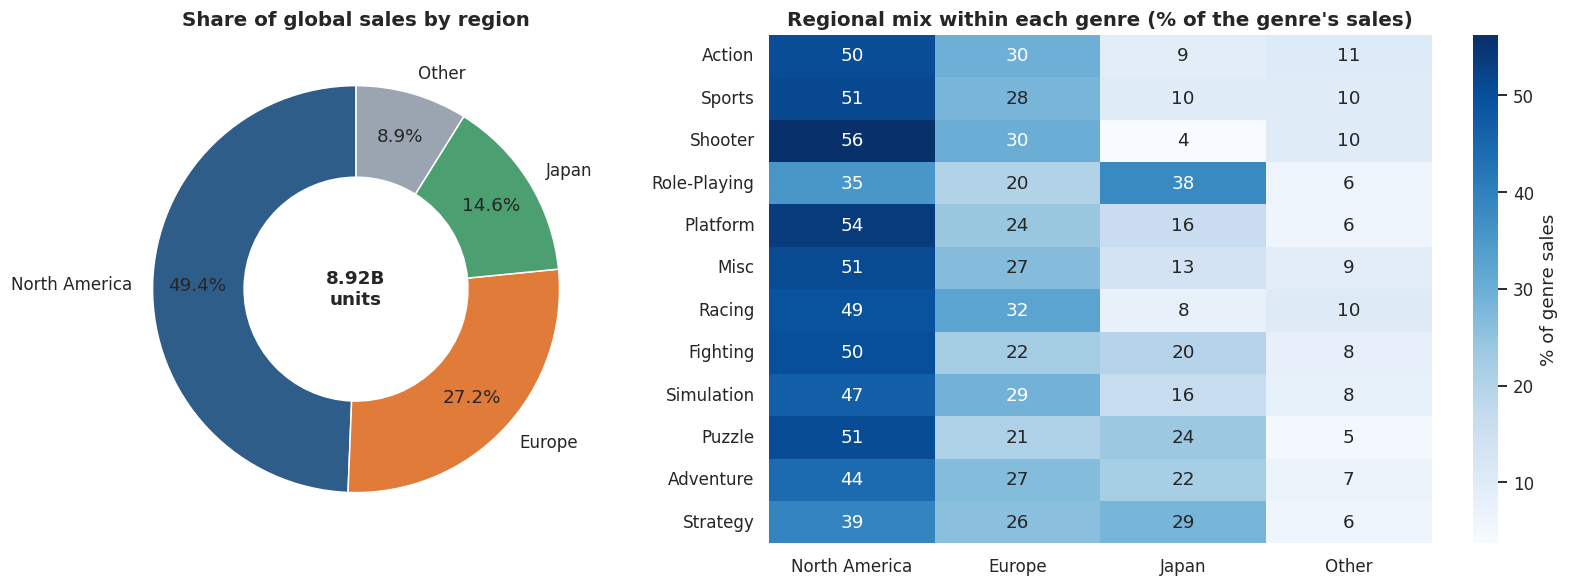

North America    49.4
Europe           27.2
Japan            14.6
Other             8.9
dtype: float64

In [15]:
reg = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum(); reg.index = ['North America','Europe','Japan','Other']
fig, ax = plt.subplots(1,2, figsize=(15,5.5), gridspec_kw={'width_ratios':[1,1.5]})
w,_,_ = ax[0].pie(reg, labels=reg.index, autopct='%1.1f%%', startangle=90, colors=[BLUE,ORANGE,'#4C9F70',GREY], wedgeprops=dict(width=.45, edgecolor='w'), pctdistance=.78)
ax[0].set_title('Share of global sales by region'); ax[0].text(0,0,f'{TOTAL/1000:.2f}B\nunits', ha='center', va='center', fontweight='bold')
rg = df.groupby('Genre')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum(); rg.columns = ['North America','Europe','Japan','Other']
share = rg.div(rg.sum(axis=1), axis=0)*100
sns.heatmap(share.loc[g.sort_values('Total',ascending=False).index], annot=True, fmt='.0f', cmap='Blues', cbar_kws={'label':'% of genre sales'}, ax=ax[1]); ax[1].set_title("Regional mix within each genre (% of the genre's sales)"); ax[1].set_ylabel('')
save('08_regions'); (reg/reg.sum()*100).round(1)

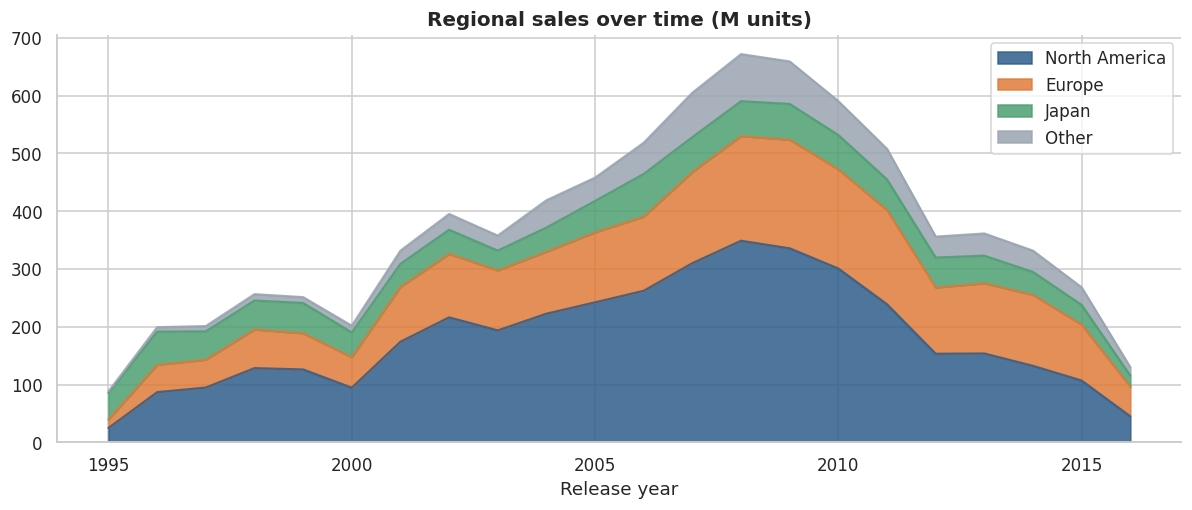

In [16]:
fig, ax = plt.subplots(figsize=(11,4.8))
ry = df[df.Year.between(1995,2016)].groupby('Year')[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']].sum(); ry.columns = ['North America','Europe','Japan','Other']
ry.plot.area(ax=ax, alpha=.85, color=[BLUE,ORANGE,'#4C9F70',GREY]); ax.set_title('Regional sales over time (M units)'); ax.set_xlabel('Release year'); save('09_regions_trend')

**Insight.** North America is half the market (49.4%), Europe 27.2%, Japan 14.6%, rest of world 8.9%. Tastes differ sharply: **Role-Playing is 38% Japan** (vs 15% market average) while **Shooters are only 4% Japan** but 56% North America. Strategy and Puzzle also over-index in Japan. A single global release plan misses these differences.

### 3.8 Is there a relationship between ratings and sales?
**Purpose:** test whether quality (critic/user scores) and age rating translate into sales. Uses only games that have scores (~7,000), because missing scores are not imputed.

Games with both scores: 7,015
Critic score vs sales  Spearman rho = 0.38 (p=8.9e-242)
User score vs sales    Spearman rho = 0.16 (p=7.8e-40)
Critic vs user score   Pearson  r   = 0.58


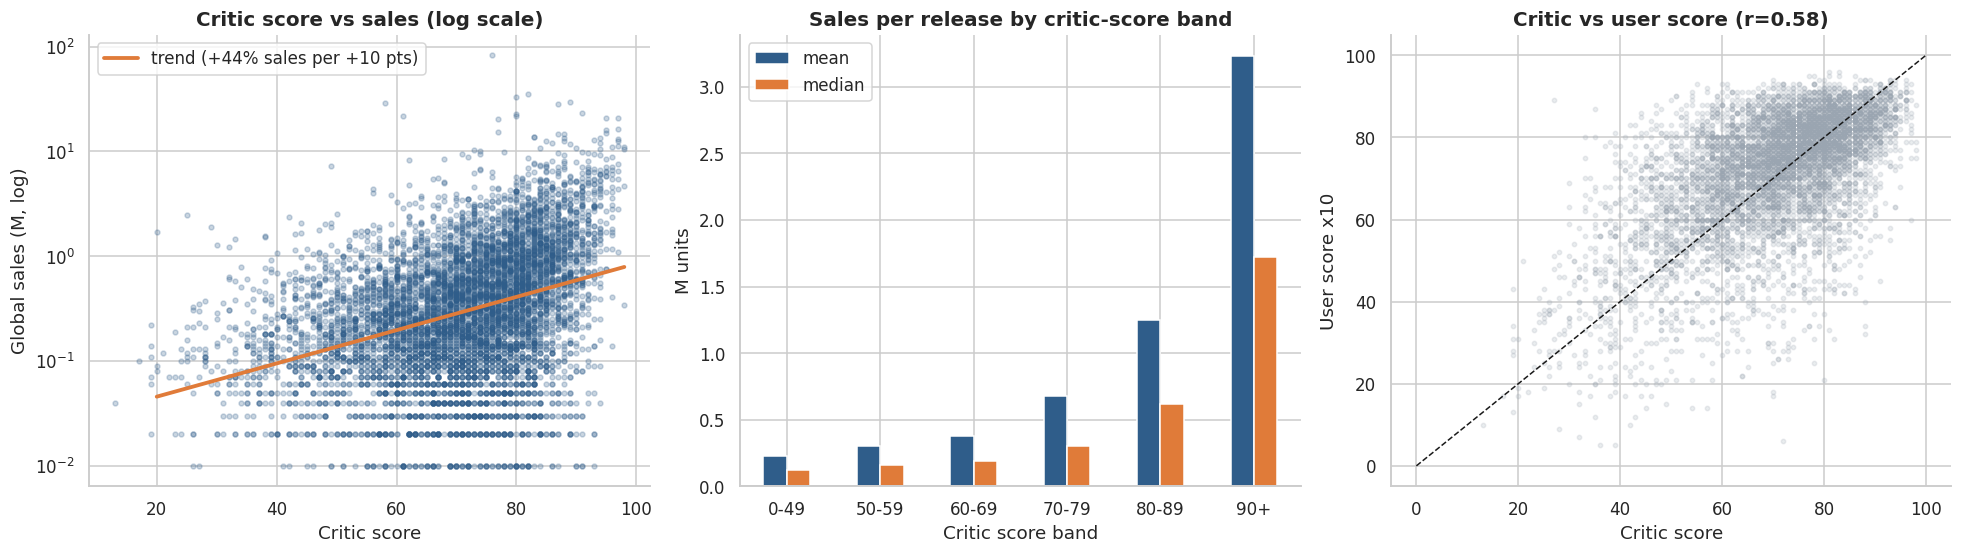

,mean,median
Critic_Band,,
0-49,0.23,0.12
50-59,0.30,0.16
60-69,0.38,0.19
70-79,0.68,0.30
80-89,1.25,0.62
90+,3.23,1.72


In [17]:
sc = df.dropna(subset=['Critic_Score','User_Score']).copy(); sc['logS'] = np.log10(sc.Global_Sales)
rc = stats.spearmanr(sc.Critic_Score, sc.Global_Sales); ru = stats.spearmanr(sc.User_Score, sc.Global_Sales); rcu = stats.pearsonr(sc.Critic_Score, sc.User_Score_100)
print(f'Games with both scores: {len(sc):,}')
print(f'Critic score vs sales  Spearman rho = {rc[0]:.2f} (p={rc[1]:.1e})')
print(f'User score vs sales    Spearman rho = {ru[0]:.2f} (p={ru[1]:.1e})')
print(f'Critic vs user score   Pearson  r   = {rcu[0]:.2f}')
fig, ax = plt.subplots(1,3, figsize=(18,5.2))
ax[0].scatter(sc.Critic_Score, sc.Global_Sales, s=10, alpha=.25, color=BLUE); ax[0].set_yscale('log'); ax[0].set_title('Critic score vs sales (log scale)'); ax[0].set_xlabel('Critic score'); ax[0].set_ylabel('Global sales (M, log)')
m, b = np.polyfit(sc.Critic_Score, sc.logS, 1); xs = np.linspace(20,98,50); ax[0].plot(xs, 10**(m*xs+b), color=ORANGE, lw=2.5, label=f'trend (+{(10**(m*10)-1)*100:.0f}% sales per +10 pts)'); ax[0].legend()
bb = df.groupby('Critic_Band', observed=True).Global_Sales.agg(['mean','median']); bb.plot.bar(ax=ax[1], color=[BLUE,ORANGE], rot=0); ax[1].set_title('Sales per release by critic-score band'); ax[1].set_xlabel('Critic score band'); ax[1].set_ylabel('M units')
ax[2].scatter(sc.Critic_Score, sc.User_Score_100, s=8, alpha=.2, color=GREY); ax[2].plot([0,100],[0,100],'k--',lw=1); ax[2].set_title(f'Critic vs user score (r={rcu[0]:.2f})'); ax[2].set_xlabel('Critic score'); ax[2].set_ylabel('User score x10')
save('10_ratings_vs_sales'); bb.round(2)

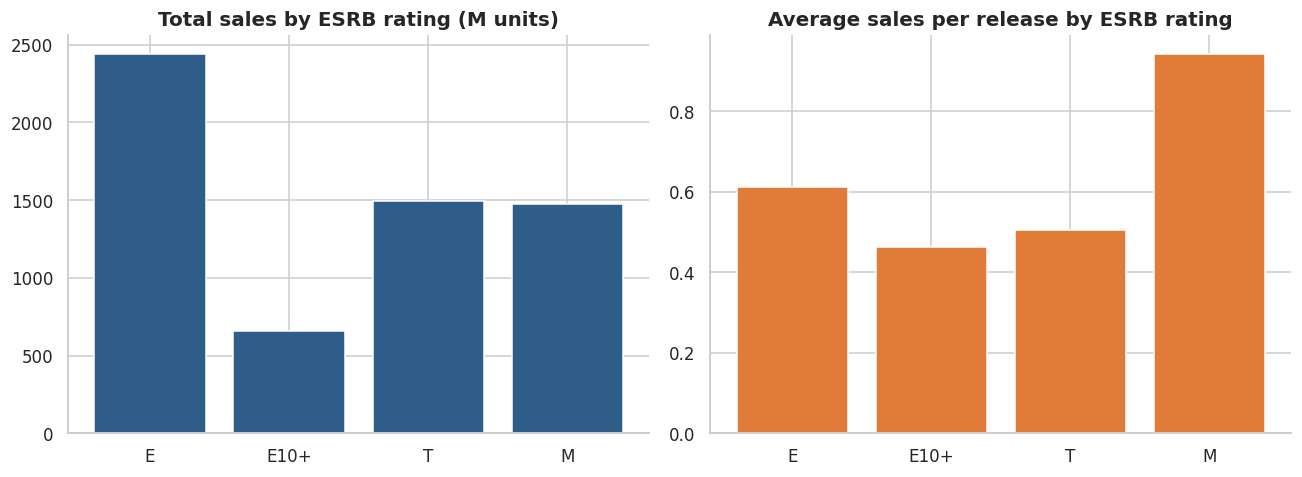

,Games,Total,Avg
Rating,,,
E,3993,2441.23,0.61
E10+,1419,655.81,0.46
T,2961,1494.40,0.50
M,1563,1473.84,0.94


In [18]:
r = df.dropna(subset=['Rating']); r = r[r.Rating.isin(['E','E10+','T','M'])]
rr = r.groupby('Rating').agg(Games=('Name','count'), Total=('Global_Sales','sum'), Avg=('Global_Sales','mean')).loc[['E','E10+','T','M']]
fig, ax = plt.subplots(1,2, figsize=(12,4.5)); ax[0].bar(rr.index, rr.Total, color=BLUE); ax[0].set_title('Total sales by ESRB rating (M units)'); ax[1].bar(rr.index, rr.Avg, color=ORANGE); ax[1].set_title('Average sales per release by ESRB rating')
save('11_esrb'); rr.round(2)

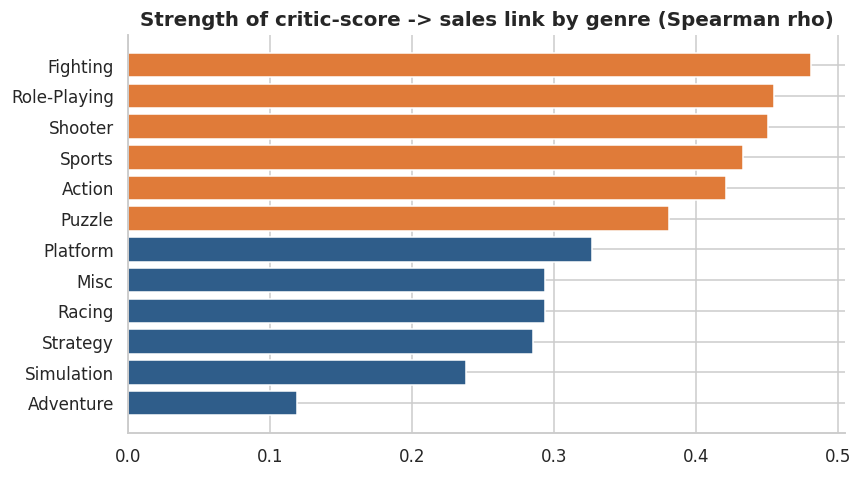

,n,rho
Genre,,
Adventure,265.0,0.12
Simulation,306.0,0.24
Strategy,284.0,0.29
Racing,598.0,0.29
Misc,396.0,0.29
Platform,406.0,0.33
Puzzle,121.0,0.38
Action,1677.0,0.42
Sports,972.0,0.43


In [19]:
# Do scores matter equally in every genre? (critic score vs sales, Spearman)
gc = sc.groupby('Genre').apply(lambda x: pd.Series({'n':len(x),'rho':stats.spearmanr(x.Critic_Score, x.Global_Sales)[0]})).sort_values('rho')
plt.figure(figsize=(8,4.5)); plt.barh(gc.index, gc.rho, color=[ORANGE if v>=gc.rho.median() else BLUE for v in gc.rho]); plt.title('Strength of critic-score -> sales link by genre (Spearman rho)'); save('12_score_by_genre'); gc.round(2)

**Insight.** Quality and sales are **positively but moderately** related (critic-score Spearman rho ~0.38; user score only ~0.16). The effect is non-linear: releases scoring **90+ average 3.2M units - about 14x** games scoring under 50 (0.23M), and 80-89 games average 1.25M. Critics and users broadly agree (r ~0.58). A high score does not guarantee a hit, but a low score almost guarantees a small one. Mature-rated (M) games have the highest average (0.94M) while Everyone (E) has the highest total volume (2.4B).

### 3.9 Post-2016 cross-check with the PS4 / Xbox One files

Missing Year/Publisher in supplementary files: 317 / 317 of 1647
         Titles   Total   Avg
Console                      
PS4        1034  595.64  0.58
XOne        613  269.03  0.44
         North America  Europe  Japan  Rest of World
Console                                             
PS4               35.5    43.2    5.8           15.5
XOne              60.5    30.2    0.2            9.1


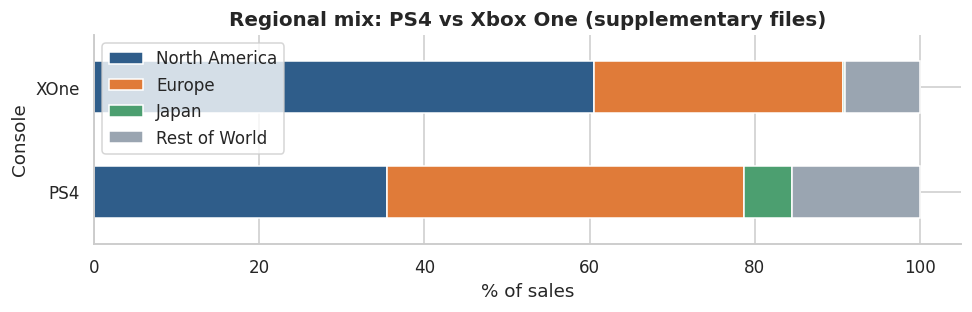

Top genres on PS4/XOne for 2017+ releases:
Genre
Action              60.4
Shooter             48.0
Sports              33.8
Action-Adventure    32.0
Role-Playing        19.2
Name: Global, dtype: float64


In [20]:
ps4 = pd.read_csv('../data/raw/PS4_GamesSales.csv', encoding='latin-1'); xo = pd.read_csv('../data/raw/XboxOne_GameSales.csv', encoding='latin-1')
for d_,n_ in ((ps4,'PS4'),(xo,'XOne')): d_['Console'] = n_
both = pd.concat([ps4, xo]); cols = ['North America','Europe','Japan','Rest of World']
print('Missing Year/Publisher in supplementary files:', both.Year.isna().sum(), '/', both.Publisher.isna().sum(), 'of', len(both))
summ = both.groupby('Console').agg(Titles=('Game','count'), Total=('Global','sum'), Avg=('Global','mean'))
mix = both.groupby('Console')[cols].sum(); mix = mix.div(mix.sum(axis=1), axis=0)*100
print(summ.round(2)); print(mix.round(1))
ax = mix.plot.barh(stacked=True, figsize=(9,3), color=[BLUE,ORANGE,'#4C9F70',GREY]); ax.set_title('Regional mix: PS4 vs Xbox One (supplementary files)'); ax.set_xlabel('% of sales'); save('13_ps4_vs_xone')
late = both[both.Year>=2017].groupby('Genre').Global.sum().sort_values(ascending=False).head(5); print('Top genres on PS4/XOne for 2017+ releases:'); print(late.round(1))

**Insight.** Using the newer snapshots, PS4 outsells Xbox One about 2.2x in these files (596M vs 269M units). PS4 is Europe-heavy (43% of its sales vs 30% for Xbox One) and has a small Japan base (6%), while Xbox One is 60% North America and almost absent in Japan (0.2%). Shooter and Action stay dominant for 2017+ releases - the same genres that lead in the main dataset.

## 5. Dashboard
The interactive dashboard is delivered as an **Excel workbook** (`dashboard/Video_Game_Dashboard.xlsx` - dropdown filters for Genre, Platform maker and year range drive every KPI and chart) and a **Streamlit app** (`dashboard/app.py`, slicers + interactive Plotly charts). See the README for how to open each.

## 6. Insights & Recommendations
**Main insights**
1. **A hit-driven market.** Top 1% of releases = 21% of units; top 10% = 59%; 35% sold < 100k. Winning means a few big bets, not many small ones.
2. **Genre:** Action (19.6%), Sports (14.9%) and Shooter (11.8%) lead in volume; Platform, Shooter and RPG earn the most *per title*. Adventure, Strategy and Puzzle are crowded or small - low return per release.
3. **Platforms are 5-8 year windows.** Sony (3.59B) and Nintendo (3.50B) dominate; Microsoft is ~40% of either. Value is highest early/mid-lifecycle.
4. **Publishers:** top 10 control ~71% of units. Nintendo wins on per-title efficiency (2.5M vs 0.7-0.9M for EA/Activision/Sony).
5. **Time trend:** peak 2008 (672M), steep decline after 2011 in this (mostly physical-sales) data; fewer but bigger releases.
6. **Regions:** NA 49%, EU 27%, JP 15%, other 9%. Japan is RPG/Strategy/Puzzle/Adventure territory; shooters barely sell there.
7. **Quality pays, non-linearly:** 90+ critic-score games sell ~14x games under 50; user score matters less than critic score.

**Recommendations for a gaming company**
- **Portfolio:** concentrate budget on Action/Shooter/RPG/Platform franchises with sequel potential; cap spend on Adventure/Strategy/Puzzle unless production cost is low.
- **Quality gate:** invest in QA/polish to reach 80+ critic scores before launch; the sales jump between 70s and 80s/90s is the largest of any variable tested.
- **Platform plan:** launch on current-gen platforms early in their lifecycle and go multi-platform (GTA V, Call of Duty pattern) - multi-platform titles dominate the title ranking.
- **Regional localization:** lead with NA/EU for shooters, sports and racing; build a Japan-specific plan for RPGs (Japan = 38% of RPG sales) and puzzle/strategy.
- **Competition:** a publisher with fewer releases but stronger franchises beats volume (Nintendo vs EA) - differentiate through IP, not catalog size.
- **Partnerships/acquisition:** top publishers are concentrated; a mid-size studio's best route may be a co-publishing deal with a top-10 publisher for distribution.

**Limitations.** Data is a 2016 snapshot dominated by physical retail (no mobile/digital-only, no revenue or budget, so ROI cannot be computed); ~50% of games have no scores; 2016 is partial; correlation is not causation (well-funded games are both better-reviewed and heavily marketed).